In [1]:
# DATA PREPROCESSING AND INITIAL SETUP

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy import stats
from scipy.signal import find_peaks
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Temperature-Soil Moisture Research Analysis")
print("_" * 50)
print("Phase 1: Data Preprocessing and Initial Setup")
print()

# Load all station data
def load_all_stations_data():
    """Load data from all weather stations"""
    data_dir = 'datasets/Revised_Final_Data'
    files = glob.glob(os.path.join(data_dir, 'Station*_Revised_Final_Data.csv'))
    
    stations_data = {}
    data_summary = []
    
    for fp in files:
        station = os.path.basename(fp).split('_')[0]
        
        df = pd.read_csv(fp, parse_dates=['Date'], index_col='Date')
        stations_data[station] = df
        
        # Basic info
        data_summary.append({
            'Station': station,
            'Start_Date': df.index.min(),
            'End_Date': df.index.max(),
            'Total_Records': len(df),
            'Missing_SWC_5': df['SWC_5'].isna().sum(),
            'Missing_T_5': df['T_5'].isna().sum(),
            'Missing_Tair': df['Tair'].isna().sum()
        })
    
    summary_df = pd.DataFrame(data_summary)
    print(f"\nLoaded {len(stations_data)} stations successfully.")
    print(f"Date range: {summary_df['Start_Date'].min()} to {summary_df['End_Date'].max()}")
    
    return stations_data, summary_df

# Load the data
stations_data, data_summary = load_all_stations_data()
display(data_summary)

Temperature-Soil Moisture Research Analysis
__________________________________________________
Phase 1: Data Preprocessing and Initial Setup


Loaded 6 stations successfully.
Date range: 2015-01-01 00:00:00 to 2020-12-31 23:00:00


,Station,Start_Date,End_Date,Total_Records,Missing_SWC_5,Missing_T_5,Missing_Tair
0,Station1,2015-01-01,2020-12-31 23:00:00,52560,0,0,0
1,Station2,2015-01-01,2020-12-31 23:00:00,52560,0,0,0
2,Station3,2015-01-01,2020-12-31 23:00:00,52560,0,0,0
3,Station4,2015-01-01,2020-12-31 23:00:00,52560,0,0,0
4,Station5,2015-01-01,2020-12-31 23:00:00,52560,0,0,0
5,Station6,2015-01-01,2020-12-31 23:00:00,52560,0,0,0


In [3]:
# DESCRIPTIVE STATISTICS AND DATA VISUALIZATION
# This cell implements Phase 1.2 descriptive statistics analysis providing comprehensive overview
# of temperature and moisture patterns across all variables and stations. Calculates central tendency,
# variability, and distribution statistics for both temperature and soil water content variables.

def generate_descriptive_statistics(stations_data):
    """Generate comprehensive descriptive statistics for all variables"""
    print("Phase 1.2: Descriptive Statistics Analysis")
    print("-" * 60)
    
    # Variables of interest
    temp_vars = ['Tair', 'T_5', 'T_10', 'T_20', 'T_50']
    swc_vars = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50']
    
    all_stats = []
    
    for station_name, df in stations_data.items():
        print(f"\nAnalyzing {station_name} descriptive statistics...")
        
        for var in temp_vars + swc_vars:
            if var in df.columns:
                data = df[var].dropna()
                if len(data) > 0:
                    stats_dict = {
                        'Station': station_name,
                        'Variable': var,
                        'Type': 'Temperature' if var.startswith('T') or var == 'Tair' else 'Soil_Moisture',
                        'Depth': var.split('_')[-1] if '_' in var else 'Air',
                        'Count': len(data),
                        'Mean': data.mean(),
                        'Std': data.std(),
                        'Min': data.min(),
                        'Q25': data.quantile(0.25),
                        'Median': data.median(),
                        'Q75': data.quantile(0.75),
                        'Max': data.max(),
                        'Range': data.max() - data.min(),
                        'CV': data.std() / data.mean() if data.mean() != 0 else np.nan,
                        'Skewness': data.skew(),
                        'Kurtosis': data.kurtosis()
                    }
                    all_stats.append(stats_dict)
    
    return pd.DataFrame(all_stats)

# Generate descriptive statistics
desc_stats = generate_descriptive_statistics(stations_data)

# Display temperature statistics summary
print("\nTEMPERATURE STATISTICS SUMMARY:")
print("=" * 50)
temp_stats = desc_stats[desc_stats['Type'] == 'Temperature']
temp_summary = temp_stats.groupby('Depth').agg({
    'Mean': ['mean', 'std'],
    'Range': ['mean', 'std'],
    'CV': 'mean'
}).round(2)
display(temp_summary)

# Display soil moisture statistics summary  
print("\nSOIL MOISTURE STATISTICS SUMMARY:")
print("=" * 50)
swc_stats = desc_stats[desc_stats['Type'] == 'Soil_Moisture']
swc_summary = swc_stats.groupby('Depth').agg({
    'Mean': ['mean', 'std'],
    'Range': ['mean', 'std'], 
    'CV': 'mean'
}).round(2)
display(swc_summary)
#coefficient of variation

Phase 1.2: Descriptive Statistics Analysis
------------------------------------------------------------

Analyzing Station1 descriptive statistics...

Analyzing Station2 descriptive statistics...

Analyzing Station3 descriptive statistics...

Analyzing Station4 descriptive statistics...

Analyzing Station5 descriptive statistics...

Analyzing Station6 descriptive statistics...

TEMPERATURE STATISTICS SUMMARY:


Mean         Range            CV
        mean   std    mean     std  mean
Depth                                   
10     22.30  0.61   40.24    1.69  0.38
20     21.68  1.90   34.68    3.85  0.39
5      22.30  0.57   45.46    2.43  0.40
50     22.45  0.48   28.27    2.78  0.29
Air    18.41  2.10  107.07  117.47  0.67


SOIL MOISTURE STATISTICS SUMMARY:


Mean       Range          CV
       mean   std  mean   std  mean
Depth                              
10     0.19  0.05  0.29  0.06  0.27
20     0.20  0.06  0.26  0.08  0.25
5      0.17  0.05  0.30  0.06  0.31
50     0.23  0.11  0.29  0.17  0.24

In [2]:
# TEMPERATURE-MOISTURE CORRELATION ANALYSIS
# This cell implements Phase 1.3 correlation analysis to address the core research question.
# Calculates Pearson and Spearman correlations between temperature variables (air and soil at multiple depths)
# and soil water content at different depths across all stations. Tests statistical significance.

def analyze_temperature_moisture_correlations(stations_data):
    """
    Analyze correlations between temperature and soil moisture at different depths
    This addresses our primary research question directly
    """
    print("Phase 1.3: Temperature-Moisture Correlation Analysis")
    print("-" * 60)
    
    # Define variables of interest
    temp_vars = ['Tair', 'T_5', 'T_10', 'T_20', 'T_50']
    swc_vars = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50']
    
    correlation_results = []
    
    for station_name, df in stations_data.items():
        print(f"\nAnalyzing {station_name}...")
        
        for temp_var in temp_vars:
            for swc_var in swc_vars:
                if temp_var in df.columns and swc_var in df.columns:
                    # Remove missing values
                    valid_data = df[[temp_var, swc_var]].dropna()
                    
                    if len(valid_data) > 100:  # Minimum data requirement
                        # Calculate correlations
                        pearson_r, pearson_p = stats.pearsonr(valid_data[temp_var], valid_data[swc_var])
                        spearman_r, spearman_p = stats.spearmanr(valid_data[temp_var], valid_data[swc_var])
                        
                        correlation_results.append({
                            'Station': station_name,
                            'Temperature_Var': temp_var,
                            'SWC_Var': swc_var,
                            'Pearson_R': pearson_r,
                            'Pearson_P': pearson_p,
                            'Spearman_R': spearman_r,
                            'Spearman_P': spearman_p,
                            'N_Samples': len(valid_data),
                            'Temp_Depth': temp_var.split('_')[-1] if '_' in temp_var else 'Air',
                            'SWC_Depth': swc_var.split('_')[-1]
                        })
    
    return pd.DataFrame(correlation_results)

# Perform correlation analysis
correlation_df = analyze_temperature_moisture_correlations(stations_data)

# Display summary of key findings
print(f"\nKEY RESEARCH FINDINGS - Temperature-Moisture Correlations:")
print("=" * 70)

# Average correlations by depth
depth_summary = correlation_df.groupby(['Temp_Depth', 'SWC_Depth']).agg({
    'Pearson_R': ['mean', 'std'],
    'Spearman_R': ['mean', 'std'],
    'N_Samples': 'mean'
}).round(3)

print("\nAverage Pearson Correlations by Depth Combination:")
print(depth_summary['Pearson_R'])

# Show strongest correlations
print(f"\nStrongest Temperature-Moisture Correlations:")
strongest = correlation_df.nlargest(5, 'Pearson_R')[['Station', 'Temperature_Var', 'SWC_Var', 'Pearson_R', 'Pearson_P']]
display(strongest)

print(f"\nMost Negative Temperature-Moisture Correlations:")
most_negative = correlation_df.nsmallest(5, 'Pearson_R')[['Station', 'Temperature_Var', 'SWC_Var', 'Pearson_R', 'Pearson_P']]
display(most_negative)


Phase 1.3: Temperature-Moisture Correlation Analysis
------------------------------------------------------------

Analyzing Station1...

Analyzing Station2...

Analyzing Station3...

Analyzing Station4...

Analyzing Station5...

Analyzing Station6...

KEY RESEARCH FINDINGS - Temperature-Moisture Correlations:

Average Pearson Correlations by Depth Combination:
                       mean    std
Temp_Depth SWC_Depth              
10         10        -0.524  0.038
           20        -0.505  0.070
           5         -0.537  0.031
           50        -0.378  0.123
20         10        -0.511  0.064
           20        -0.472  0.098
           5         -0.516  0.078
           50        -0.378  0.114
5          10        -0.509  0.039
           20        -0.490  0.073
           5         -0.522  0.029
           50        -0.363  0.125
50         10        -0.541  0.045
           20        -0.541  0.061
           5         -0.535  0.043
           50        -0.440  0.105
Air   

,Station,Temperature_Var,SWC_Var,Pearson_R,Pearson_P
3,Station1,Tair,SWC_50,0.023435,7.729162e-08
2,Station1,Tair,SWC_20,-0.010782,1.343867e-02
0,Station1,Tair,SWC_5,-0.043551,1.703239e-23
1,Station1,Tair,SWC_10,-0.065702,2.237791e-51
63,Station4,Tair,SWC_50,-0.137694,8.737747e-221



Most Negative Temperature-Moisture Correlations:


,Station,Temperature_Var,SWC_Var,Pearson_R,Pearson_P
98,Station5,T_50,SWC_20,-0.643255,0.0
97,Station5,T_50,SWC_10,-0.614206,0.0
72,Station4,T_20,SWC_5,-0.598615,0.0
96,Station5,T_50,SWC_5,-0.597833,0.0
90,Station5,T_10,SWC_20,-0.587673,0.0



Creating Temperature-Moisture Correlation Visualizations
------------------------------------------------------------


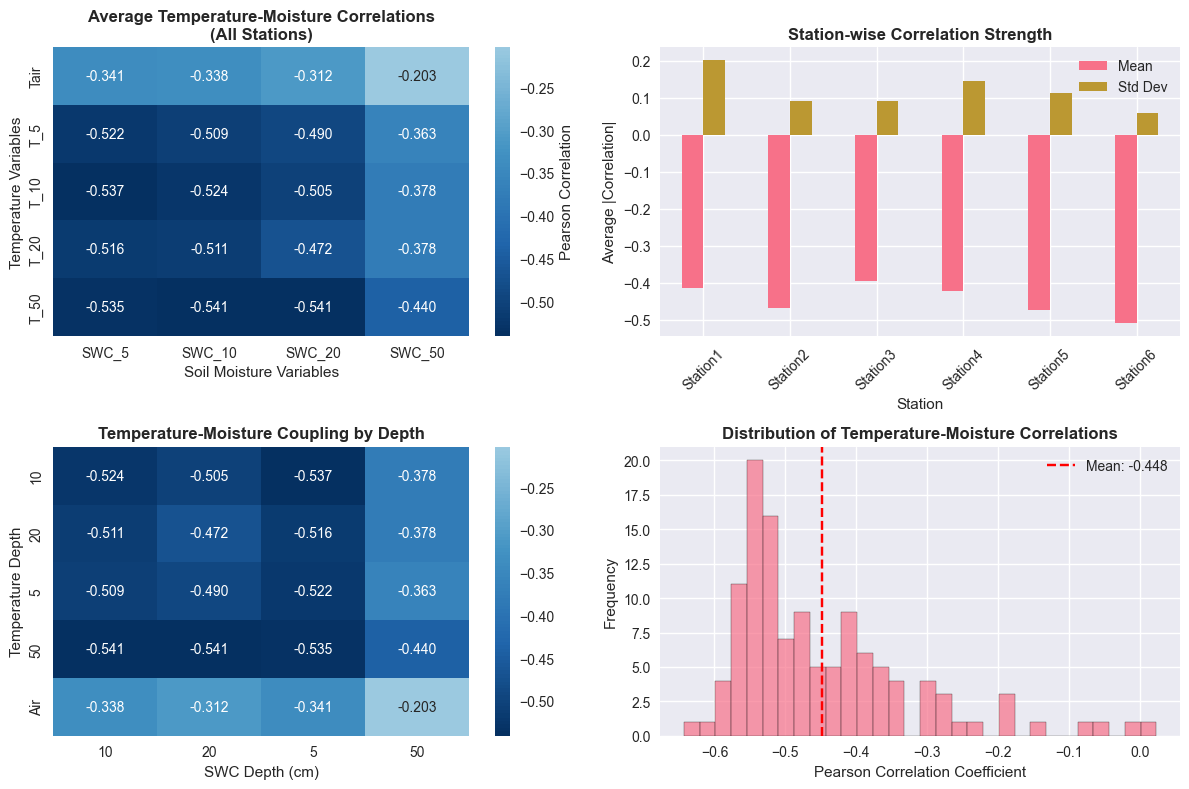


KEY INSIGHTS FROM CORRELATION ANALYSIS:
Total correlation pairs analyzed: 120
Mean correlation strength: -0.448
Correlation range: -0.643 to 0.023
Strongest coupling: T_50 vs SWC_20
Statistically significant correlations (p<0.05): 120 / 120 (100.0%)


In [4]:
# CORRELATION HEATMAP VISUALIZATION
# This cell creates comprehensive visualization of temperature-moisture correlations including
# heatmaps showing relationships across depths, station-wise correlation strength analysis,
# and distribution of correlation coefficients to provide visual representation of findings.

def create_correlation_heatmap(correlation_df):
    """Create correlation heatmap showing temperature-moisture relationships"""
    print("\nCreating Temperature-Moisture Correlation Visualizations")
    print("-" * 60)
    
    # Prepare data for heatmap
    temp_vars = ['Tair', 'T_5', 'T_10', 'T_20', 'T_50']
    swc_vars = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50']
    
    # Average correlations across all stations
    avg_corr = correlation_df.groupby(['Temperature_Var', 'SWC_Var'])['Pearson_R'].mean().unstack()
    
    # Reorder to match depth sequence
    avg_corr = avg_corr.reindex(temp_vars, axis=0)
    avg_corr = avg_corr.reindex(swc_vars, axis=1)
    
    # Create the heatmap
    plt.figure(figsize=(12, 8))
    
    # Main correlation heatmap
    plt.subplot(2, 2, 1)
    sns.heatmap(avg_corr, annot=True, cmap='RdBu_r', center=0, 
                fmt='.3f', cbar_kws={'label': 'Pearson Correlation'})
    plt.title('Average Temperature-Moisture Correlations\n(All Stations)', fontsize=12, fontweight='bold')
    plt.xlabel('Soil Moisture Variables')
    plt.ylabel('Temperature Variables')
    
    # Station-wise correlation strength
    plt.subplot(2, 2, 2)
    station_strength = correlation_df.groupby('Station')['Pearson_R'].agg(['mean', 'std'])
    station_strength.plot(kind='bar', ax=plt.gca())
    plt.title('Station-wise Correlation Strength', fontsize=12, fontweight='bold')
    plt.xlabel('Station')
    plt.ylabel('Average |Correlation|')
    plt.xticks(rotation=45)
    plt.legend(['Mean', 'Std Dev'])
    
    # Depth-wise analysis
    plt.subplot(2, 2, 3)
    depth_analysis = correlation_df.groupby(['Temp_Depth', 'SWC_Depth'])['Pearson_R'].mean().unstack()
    sns.heatmap(depth_analysis, annot=True, cmap='RdBu_r', center=0, fmt='.3f')
    plt.title('Temperature-Moisture Coupling by Depth', fontsize=12, fontweight='bold')
    plt.xlabel('SWC Depth (cm)')
    plt.ylabel('Temperature Depth')
    
    # Distribution of correlations
    plt.subplot(2, 2, 4)
    plt.hist(correlation_df['Pearson_R'], bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(correlation_df['Pearson_R'].mean(), color='red', linestyle='--', 
                label=f'Mean: {correlation_df["Pearson_R"].mean():.3f}')
    plt.xlabel('Pearson Correlation Coefficient')
    plt.ylabel('Frequency')
    plt.title('Distribution of Temperature-Moisture Correlations', fontsize=12, fontweight='bold')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return avg_corr

# Create correlation visualizations
avg_correlation_matrix = create_correlation_heatmap(correlation_df)

# Key insights from correlation analysis
print("\nKEY INSIGHTS FROM CORRELATION ANALYSIS:")
print("=" * 60)
print(f"Total correlation pairs analyzed: {len(correlation_df)}")
print(f"Mean correlation strength: {correlation_df['Pearson_R'].mean():.3f}")
print(f"Correlation range: {correlation_df['Pearson_R'].min():.3f} to {correlation_df['Pearson_R'].max():.3f}")
print(f"Strongest coupling: {correlation_df.loc[correlation_df['Pearson_R'].abs().idxmax(), 'Temperature_Var']} vs {correlation_df.loc[correlation_df['Pearson_R'].abs().idxmax(), 'SWC_Var']}")

# Statistical significance summary
significant_corrs = correlation_df[correlation_df['Pearson_P'] < 0.05]
print(f"Statistically significant correlations (p<0.05): {len(significant_corrs)} / {len(correlation_df)} ({len(significant_corrs)/len(correlation_df)*100:.1f}%)")



PHASE 2: TEMPORAL DYNAMICS ANALYSIS
Goal: Characterize time-dependent temperature-moisture relationships

Phase 2.1: Diurnal Pattern Analysis for Station1
------------------------------------------------------------


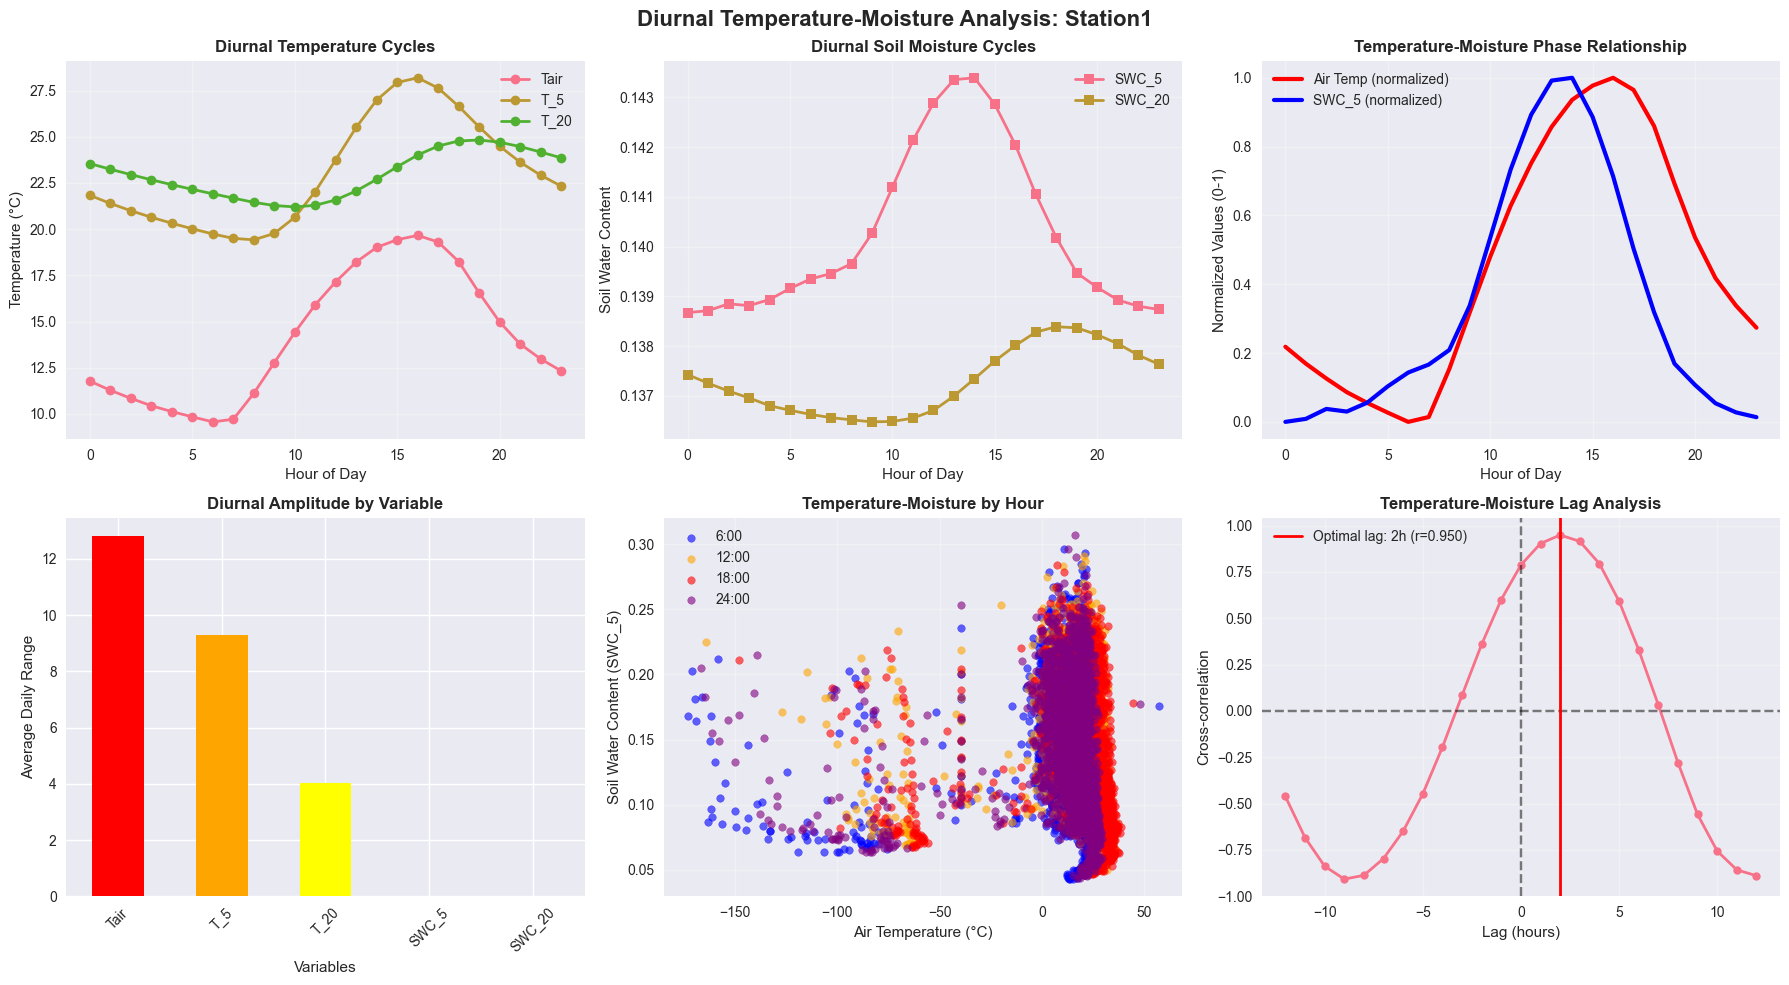

In [5]:
# PHASE 2: TEMPORAL DYNAMICS ANALYSIS
# This cell implements Phase 2 temporal dynamics analysis characterizing time-dependent relationships.
# Analyzes diurnal patterns, cross-correlation with lag analysis, and phase relationships
# between temperature and moisture variables. Tests Hypothesis H3 regarding temporal lag effects.

print("\n" + "="*70)
print("PHASE 2: TEMPORAL DYNAMICS ANALYSIS")
print("="*70)
print("Goal: Characterize time-dependent temperature-moisture relationships")

# Phase 2.1: Diurnal Pattern Analysis
def analyze_diurnal_patterns(stations_data, station_name='Station1'):
    """
    Analyze diurnal (daily) patterns in temperature-moisture relationships
    Tests Hypothesis H3: Temperature leads moisture changes by 2-6 hours
    """
    print(f"\nPhase 2.1: Diurnal Pattern Analysis for {station_name}")
    print("-" * 60)
    
    df = stations_data[station_name].copy()
    
    # Add time variables
    df['hour'] = df.index.hour
    df['day'] = df.index.date
    
    # Calculate diurnal patterns for key variables
    temp_vars = ['Tair', 'T_5', 'T_20']
    swc_vars = ['SWC_5', 'SWC_20']
    
    # Hourly averages
    diurnal_patterns = df.groupby('hour')[temp_vars + swc_vars].mean()
    
    # Create comprehensive diurnal visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Plot 1: Temperature diurnal cycles
    ax1 = axes[0, 0]
    for var in temp_vars:
        if var in diurnal_patterns.columns:
            ax1.plot(diurnal_patterns.index, diurnal_patterns[var], 
                    marker='o', linewidth=2, label=var)
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Temperature (°C)')
    ax1.set_title('Diurnal Temperature Cycles', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Soil moisture diurnal cycles
    ax2 = axes[0, 1]
    for var in swc_vars:
        if var in diurnal_patterns.columns:
            ax2.plot(diurnal_patterns.index, diurnal_patterns[var], 
                    marker='s', linewidth=2, label=var)
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Soil Water Content')
    ax2.set_title('Diurnal Soil Moisture Cycles', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Temperature vs Moisture phase relationship
    ax3 = axes[0, 2]
    # Normalize for comparison (0-1 scale)
    if 'Tair' in diurnal_patterns.columns and 'SWC_5' in diurnal_patterns.columns:
        tair_norm = (diurnal_patterns['Tair'] - diurnal_patterns['Tair'].min()) / (diurnal_patterns['Tair'].max() - diurnal_patterns['Tair'].min())
        swc5_norm = (diurnal_patterns['SWC_5'] - diurnal_patterns['SWC_5'].min()) / (diurnal_patterns['SWC_5'].max() - diurnal_patterns['SWC_5'].min())
        
        ax3.plot(diurnal_patterns.index, tair_norm, 'r-', linewidth=3, label='Air Temp (normalized)')
        ax3.plot(diurnal_patterns.index, swc5_norm, 'b-', linewidth=3, label='SWC_5 (normalized)')
        ax3.set_xlabel('Hour of Day')
        ax3.set_ylabel('Normalized Values (0-1)')
        ax3.set_title('Temperature-Moisture Phase Relationship', fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # Plot 4: Diurnal amplitude analysis
    ax4 = axes[1, 0]
    daily_ranges = df.groupby('day')[temp_vars + swc_vars].apply(lambda x: x.max() - x.min()).mean()
    daily_ranges.plot(kind='bar', ax=ax4, color=['red', 'orange', 'yellow', 'blue', 'cyan'])
    ax4.set_xlabel('Variables')
    ax4.set_ylabel('Average Daily Range')
    ax4.set_title('Diurnal Amplitude by Variable', fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    
    # Plot 5: Hourly temperature-moisture scatter
    ax5 = axes[1, 1]
    if 'Tair' in df.columns and 'SWC_5' in df.columns:
        hours_to_plot = [6, 12, 18, 24]  # Dawn, noon, dusk, midnight
        colors = ['blue', 'orange', 'red', 'purple']
        
        for i, hour in enumerate(hours_to_plot):
            hour_data = df[df['hour'] == hour % 24]
            if len(hour_data) > 10:
                ax5.scatter(hour_data['Tair'], hour_data['SWC_5'], 
                           alpha=0.6, s=30, c=colors[i], label=f'{hour}:00')
        
        ax5.set_xlabel('Air Temperature (°C)')
        ax5.set_ylabel('Soil Water Content (SWC_5)')
        ax5.set_title('Temperature-Moisture by Hour', fontweight='bold')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    
    # Plot 6: Cross-correlation analysis (lag analysis)
    ax6 = axes[1, 2]
    if 'Tair' in df.columns and 'SWC_5' in df.columns:
        # Calculate hourly means for correlation
        hourly_data = df.groupby('hour')[['Tair', 'SWC_5']].mean()
        
        # Calculate cross-correlation with different lags
        lags = range(-12, 13)  # -12 to +12 hours
        cross_corrs = []
        
        for lag in lags:
            if lag == 0:
                corr = hourly_data['Tair'].corr(hourly_data['SWC_5'])
            elif lag > 0:
                # SWC lags behind temperature
                temp_shifted = hourly_data['Tair'].shift(-lag)
                corr = temp_shifted.corr(hourly_data['SWC_5'])
            else:
                # Temperature lags behind SWC  
                swc_shifted = hourly_data['SWC_5'].shift(lag)
                corr = hourly_data['Tair'].corr(swc_shifted)
            cross_corrs.append(corr)
        
        ax6.plot(lags, cross_corrs, 'o-', linewidth=2, markersize=6)
        ax6.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax6.axvline(x=0, color='k', linestyle='--', alpha=0.5)
        ax6.set_xlabel('Lag (hours)')
        ax6.set_ylabel('Cross-correlation')
        ax6.set_title('Temperature-Moisture Lag Analysis', fontweight='bold')
        ax6.grid(True, alpha=0.3)
        
        # Find optimal lag
        optimal_lag = lags[np.argmax(np.abs(cross_corrs))]
        max_corr = max(cross_corrs, key=abs)
        ax6.axvline(x=optimal_lag, color='red', linestyle='-', linewidth=2, 
                   label=f'Optimal lag: {optimal_lag}h (r={max_corr:.3f})')
        ax6.legend()
    
    plt.suptitle(f'Diurnal Temperature-Moisture Analysis: {station_name}', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return diurnal_patterns

# Analyze diurnal patterns for Station1
diurnal_data = analyze_diurnal_patterns(stations_data, 'Station1')



Phase 2.2: Seasonal Pattern Analysis
------------------------------------------------------------
Analyzing Station1 ...
Analyzing Station2 ...
Analyzing Station3 ...
Analyzing Station4 ...
Analyzing Station5 ...
Analyzing Station6 ...


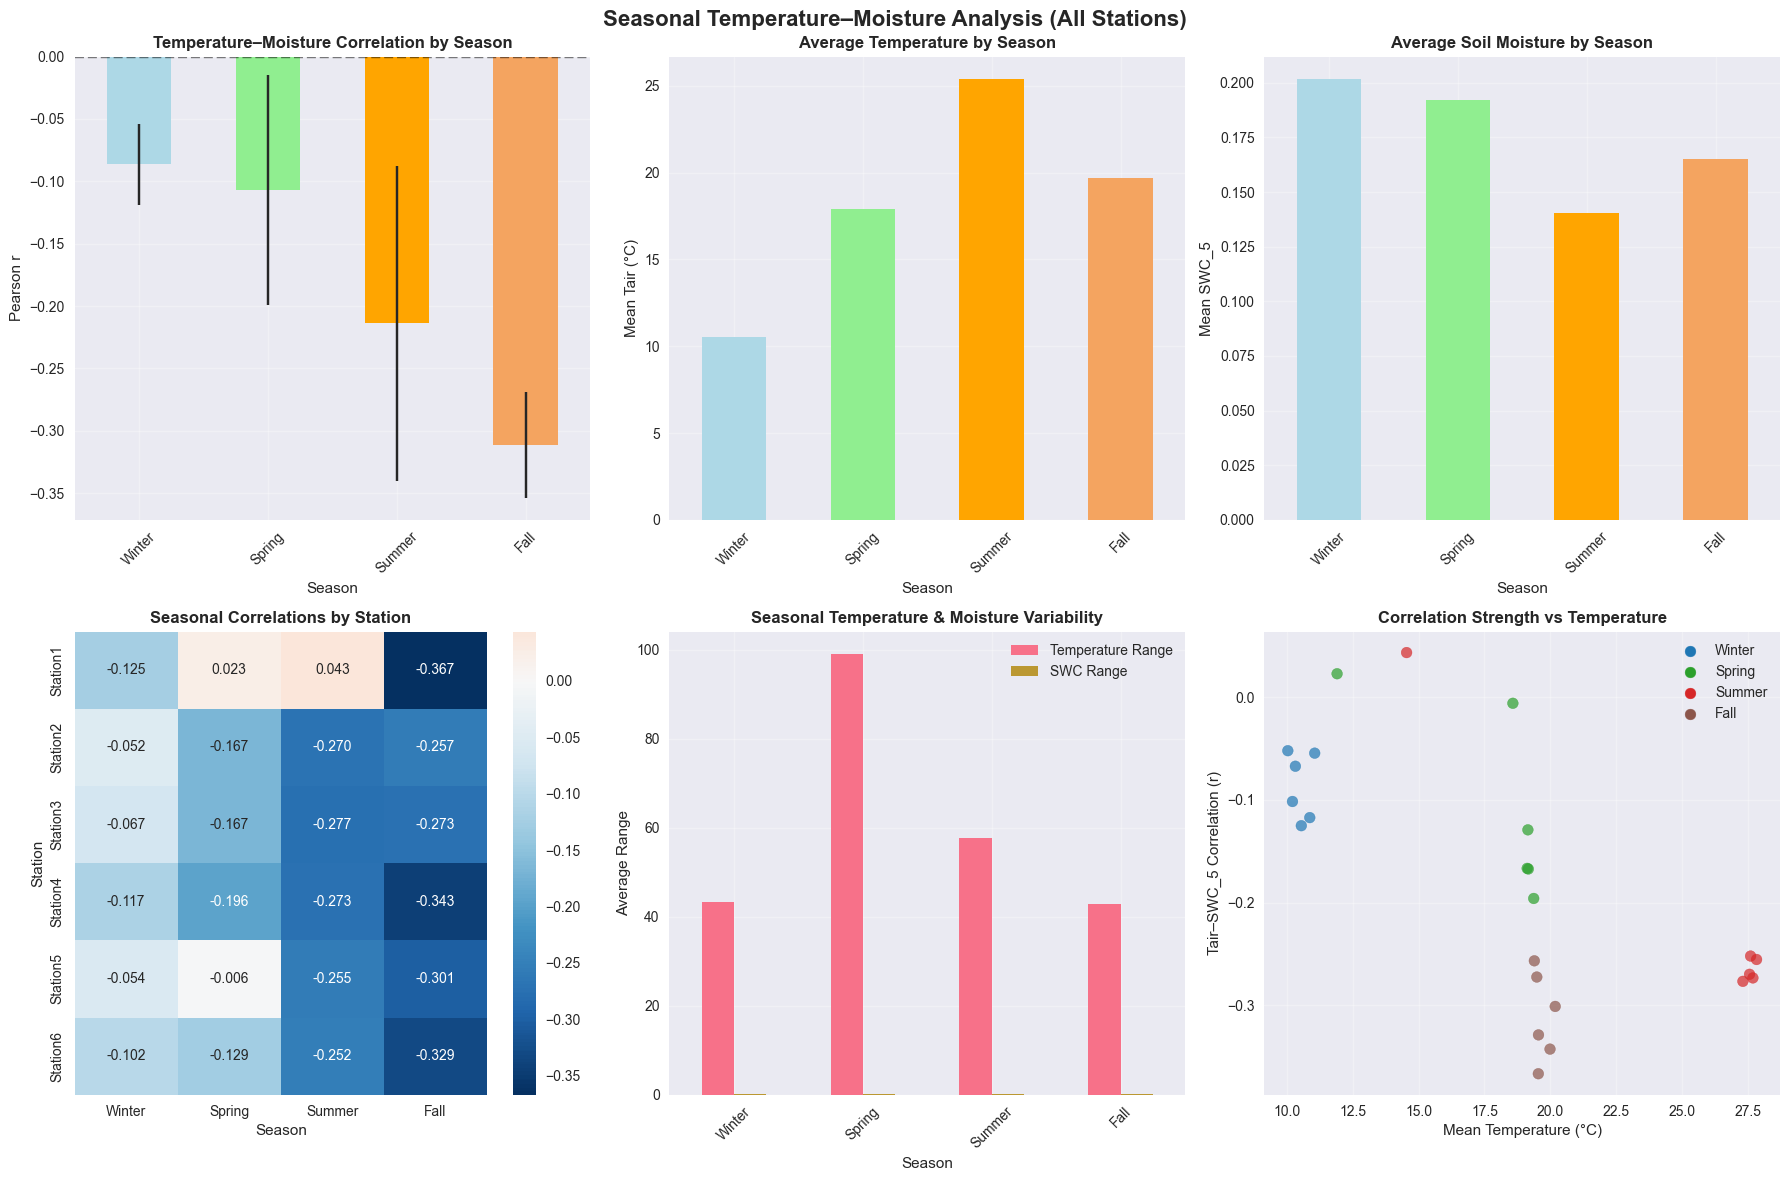


KEY SEASONAL FINDINGS (H2):
Average correlations by season:
  Winter: -0.086 (n=6)
  Spring: -0.107 (n=6)
  Summer: -0.214 (n=6)
  Fall: -0.311 (n=6)

Strongest coupling: Winter (-0.086)
Weakest coupling:   Fall (-0.311)

ANOVA (across seasons): F=9.505, p=0.0004
→ Significant seasonal differences detected (supports seasonality in coupling).

LAG ANALYSIS (H3): Temperature leads soil moisture by ~2–6 hours
  Station1: NO (lag=0h, r=-0.044, p=0.0000 sig)
  Station2: NO (lag=0h, r=-0.413, p=0.0000 sig)
  Station3: YES (lag=2h, r=-0.357, p=0.0000 sig)
  Station4: YES (lag=2h, r=-0.456, p=0.0000 sig)
  Station5: NO (lag=1h, r=-0.378, p=0.0000 sig)
  Station6: YES (lag=4h, r=-0.394, p=0.0000 sig)

H3 summary: 3/6 stations show a significant peak lag in [2, 6] hours.


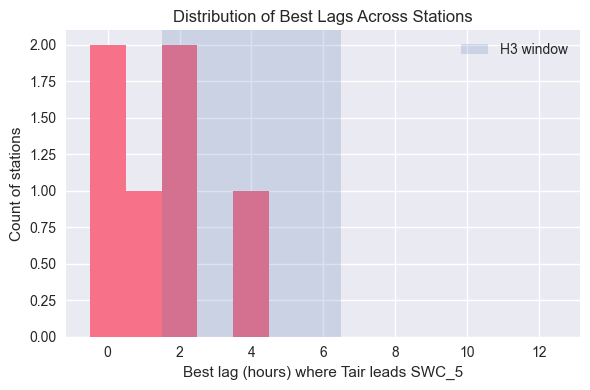

In [10]:
# PHASE 2.2 — SEASONAL & LAG ANALYSIS 
#Tests Hypothesis H3


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

SEASON_ORDER = ['Winter', 'Spring', 'Summer', 'Fall']
SEASON_COLORS = {'Winter':'lightblue','Spring':'lightgreen','Summer':'orange','Fall':'sandybrown'}
POINT_COLORS  = {'Winter':'tab:blue','Spring':'tab:green','Summer':'tab:red','Fall':'tab:brown'}

MIN_ROWS_PER_SEASON = 100      # minimum seasonal rows at station-level before computing correlation
MIN_VALID_PAIRS     = 50       # minimum valid pairs (after dropna) for correlation
LAG_RANGE_HOURS     = 12       # scan lags from 0..LAG_RANGE_HOURS (inclusive)
H3_WINDOW           = (2, 6)   # hypothesis window in hours (inclusive)

def _ensure_datetime_index(df, name_for_msg=""):
    """Ensure DataFrame has a DatetimeIndex or convert if possible."""
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df = df.copy()
            df.index = pd.to_datetime(df.index)
        except Exception as e:
            print(f"  Skipping {name_for_msg}: index not datetime-convertible ({e})")
            return None
    return df

def _add_season(df):
    """Add month/season columns based on index."""
    df = df.copy()
    df['month']  = df.index.month
    df['season'] = df['month'].map({
        12:'Winter', 1:'Winter', 2:'Winter',
         3:'Spring', 4:'Spring', 5:'Spring',
         6:'Summer', 7:'Summer', 8:'Summer',
         9:'Fall', 10:'Fall', 11:'Fall'
    })
    return df

def _safe_bar(ax, series, title, ylabel, color_map):
    """Plot a bar chart with fixed season order and nice defaults."""
    s = series.reindex(SEASON_ORDER)
    s.plot(kind='bar', ax=ax, color=[color_map.get(season, 'gray') for season in SEASON_ORDER])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

def _scan_lag_correlation_hourly(df, x_col='Tair', y_col='SWC_5',
                                 max_lag=LAG_RANGE_HOURS):
    """
    Compute lagged Pearson correlations between X(t)=Tair and Y(t)=SWC_5, where
    lag h means X leads Y by h hours (i.e., compare X(t-h) with Y(t)).
    Returns: dict with 'best_lag', 'best_corr', 'best_p', and 'corr_by_lag' (Series).
    """
    needed = {x_col, y_col}
    if not needed.issubset(df.columns):
        return {'best_lag': np.nan, 'best_corr': np.nan, 'best_p': np.nan, 'corr_by_lag': pd.Series(dtype=float)}

    # Resample to hourly to avoid sub-hourly misalignment; mean is fine for this scale.
    hourly = df[[x_col, y_col]].dropna()
    if hourly.empty:
        return {'best_lag': np.nan, 'best_corr': np.nan, 'best_p': np.nan, 'corr_by_lag': pd.Series(dtype=float)}

    hourly = hourly.resample('1H').mean().dropna()
    if len(hourly) < 24:  # too few points for meaningful lags
        return {'best_lag': np.nan, 'best_corr': np.nan, 'best_p': np.nan, 'corr_by_lag': pd.Series(dtype=float)}

    # Normalize (optional but helps numerical stability)
    X = (hourly[x_col] - hourly[x_col].mean()) / (hourly[x_col].std(ddof=0) + 1e-12)
    Y = (hourly[y_col] - hourly[y_col].mean()) / (hourly[y_col].std(ddof=0) + 1e-12)

    corr_vals = []
    p_vals    = []
    lags      = range(0, max_lag + 1)  # 0..max_lag inclusive

    for h in lags:
        # X leads Y by h hours: correlate Y(t) with X(t-h) => shift X forward by +h (so indices align)
        X_shift = X.shift(h)
        valid   = pd.concat([X_shift, Y], axis=1).dropna()
        if len(valid) >= 20:
            r, p = stats.pearsonr(valid.iloc[:,0], valid.iloc[:,1])
        else:
            r, p = (np.nan, np.nan)
        corr_vals.append(r)
        p_vals.append(p)

    corr_by_lag = pd.Series(corr_vals, index=pd.Index(lags, name='lag_hours'), name='corr')

    # Pick the best (max positive) correlation
    if np.all(np.isnan(corr_vals)):
        return {'best_lag': np.nan, 'best_corr': np.nan, 'best_p': np.nan, 'corr_by_lag': corr_by_lag}

    # argmax over finite values
    finite = np.isfinite(corr_vals)
    if not finite.any():
        return {'best_lag': np.nan, 'best_corr': np.nan, 'best_p': np.nan, 'corr_by_lag': corr_by_lag}

    best_idx  = np.nanargmax(corr_vals)
    best_lag  = list(lags)[best_idx]
    best_corr = corr_vals[best_idx]
    best_p    = p_vals[best_idx]

    return {'best_lag': best_lag, 'best_corr': best_corr, 'best_p': best_p, 'corr_by_lag': corr_by_lag}

# Main analyss fn
def analyze_seasonal_patterns(stations_data):
    """
    Phase 2.2: Seasonal Pattern Analysis
    - Computes per-station seasonal correlations between Tair and SWC_5
    - Returns a seasonal-level DataFrame and a lag-scan summary for H3
    """
    print("\nPhase 2.2: Seasonal Pattern Analysis")
    print("-" * 60)

    seasonal_results = []
    lag_results = []  # for H3

    for station_name, df in stations_data.items():
        print(f"Analyzing {station_name} ...")

        df = _ensure_datetime_index(df, station_name)
        if df is None:
            continue

        # H3 (lag) — overall per station (not seasonal; optional to split by season if you want)
        lag_out = _scan_lag_correlation_hourly(df, x_col='Tair', y_col='SWC_5',
                                               max_lag=LAG_RANGE_HOURS)
        lag_results.append({
            'Station': station_name,
            'Best_Lag_Hours': lag_out['best_lag'],
            'Best_Lag_Corr':  lag_out['best_corr'],
            'Best_Lag_P':     lag_out['best_p']
        })

        # Seasonal correlations (H2)
        df_seasonal = _add_season(df)

        for season in SEASON_ORDER:
            season_df = df_seasonal[df_seasonal['season'] == season]
            if len(season_df) > MIN_ROWS_PER_SEASON and {'Tair','SWC_5'}.issubset(season_df.columns):
                valid = season_df[['Tair','SWC_5']].dropna()
                if len(valid) > MIN_VALID_PAIRS:
                    r, p = stats.pearsonr(valid['Tair'], valid['SWC_5'])
                    seasonal_results.append({
                        'Station': station_name,
                        'Season': season,
                        'Correlation': r,
                        'P_Value': p,
                        'N_Samples': len(valid),
                        'Mean_Temp': valid['Tair'].mean(),
                        'Mean_SWC':  valid['SWC_5'].mean(),
                        'Temp_Range': valid['Tair'].max() - valid['Tair'].min(),
                        'SWC_Range':  valid['SWC_5'].max() - valid['SWC_5'].min()
                    })

    seasonal_df = pd.DataFrame(seasonal_results)
    lag_df      = pd.DataFrame(lag_results)

    #Plotting
    if seasonal_df.empty:
        print("No seasonal records passed thresholds; returning empty seasonal_df.")
    else:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Plot 1: Seasonal correlation strength (mean ± std)
        ax1 = axes[0, 0]
        corr_stats = (seasonal_df
                      .groupby('Season')['Correlation']
                      .agg(['mean','std'])
                      .reindex(SEASON_ORDER))
        corr_stats['mean'].plot(kind='bar', ax=ax1, yerr=corr_stats['std'],
                                capsize=5,
                                color=[SEASON_COLORS[s] for s in SEASON_ORDER])
        ax1.set_title('Temperature–Moisture Correlation by Season', fontweight='bold')
        ax1.set_ylabel('Pearson r')
        ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
        ax1.tick_params(axis='x', rotation=45)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Seasonal temperature patterns
        ax2 = axes[0, 1]
        seasonal_temp = (seasonal_df.groupby('Season')['Mean_Temp'].mean()
                         .reindex(SEASON_ORDER))
        _safe_bar(ax2, seasonal_temp, 'Average Temperature by Season', 'Mean Tair (°C)', SEASON_COLORS)

        # Plot 3: Seasonal moisture patterns
        ax3 = axes[0, 2]
        seasonal_swc = (seasonal_df.groupby('Season')['Mean_SWC'].mean()
                        .reindex(SEASON_ORDER))
        _safe_bar(ax3, seasonal_swc, 'Average Soil Moisture by Season', 'Mean SWC_5', SEASON_COLORS)

        # Plot 4: Station-wise seasonal comparison (heatmap)
        ax4 = axes[1, 0]
        pivot_corr = (seasonal_df
                      .pivot(index='Station', columns='Season', values='Correlation')
                      .reindex(columns=SEASON_ORDER))
        sns.heatmap(pivot_corr, annot=True, cmap='RdBu_r', center=0, ax=ax4, fmt='.3f')
        ax4.set_title('Seasonal Correlations by Station', fontweight='bold')

        # Plot 5: Seasonal variability (ranges)
        ax5 = axes[1, 1]
        seasonal_range = (seasonal_df.groupby('Season')[['Temp_Range','SWC_Range']]
                          .mean().reindex(SEASON_ORDER))
        seasonal_range.plot(kind='bar', ax=ax5)
        ax5.set_title('Seasonal Temperature & Moisture Variability', fontweight='bold')
        ax5.set_ylabel('Average Range')
        ax5.tick_params(axis='x', rotation=45)
        ax5.legend(['Temperature Range', 'SWC Range'])
        ax5.grid(True, alpha=0.3)

        # Plot 6: Correlation vs Temperature (points colored by season)
        ax6 = axes[1, 2]
        colors = seasonal_df['Season'].map(POINT_COLORS)
        ax6.scatter(seasonal_df['Mean_Temp'], seasonal_df['Correlation'], c=colors, s=60, alpha=0.7)
        # legend
        for season, color in POINT_COLORS.items():
            ax6.scatter([], [], c=color, label=season, s=60)
        ax6.set_xlabel('Mean Temperature (°C)')
        ax6.set_ylabel('Tair–SWC_5 Correlation (r)')
        ax6.set_title('Correlation Strength vs Temperature', fontweight='bold')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        plt.suptitle('Seasonal Temperature–Moisture Analysis (All Stations)',
                     fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()

    # H2 Seasonal Test
    print("\nKEY SEASONAL FINDINGS (H2):")
    print("=" * 50)
    if seasonal_df.empty:
        print("No seasonal data to summarize for H2.")
    else:
        seasonal_summary = seasonal_df.groupby('Season')['Correlation'].agg(['mean','count']).reindex(SEASON_ORDER)
        print("Average correlations by season:")
        for season in SEASON_ORDER:
            if season in seasonal_summary.index and not pd.isna(seasonal_summary.loc[season, 'mean']):
                mean_corr = seasonal_summary.loc[season, 'mean']
                count     = int(seasonal_summary.loc[season, 'count'])
                print(f"  {season}: {mean_corr:.3f} (n={count})")

        # Identify strongest / weakest
        if seasonal_summary['mean'].notna().any():
            strongest_season = seasonal_summary['mean'].idxmax()
            weakest_season   = seasonal_summary['mean'].idxmin()
            print(f"\nStrongest coupling: {strongest_season} ({seasonal_summary.loc[strongest_season, 'mean']:.3f})")
            print(f"Weakest coupling:   {weakest_season} ({seasonal_summary.loc[weakest_season, 'mean']:.3f})")

        # ANOVA across seasons (only if all 4 present)
        groups = []
        present = []
        for season in SEASON_ORDER:
            vals = seasonal_df.loc[seasonal_df['Season'] == season, 'Correlation'].values
            if len(vals) > 0:
                groups.append(vals)
                present.append(season)

        if len(groups) == 4:
            F, p = f_oneway(*groups)
            print(f"\nANOVA (across seasons): F={F:.3f}, p={p:.4f}")
            if p < 0.05:
                print("→ Significant seasonal differences detected (supports seasonality in coupling).")
            else:
                print("→ No significant seasonal differences detected.")
        else:
            missing = [s for s in SEASON_ORDER if s not in present]
            print(f"\nANOVA skipped (missing seasons: {missing}).")

    # H3: Lag (2–6h) test
    print("\nLAG ANALYSIS (H3): Temperature leads soil moisture by ~2–6 hours")
    print("=" * 50)
    if lag_df.empty:
        print("No stations had sufficient data for lag analysis.")
    else:
        # Station-level prints
        summary_rows = []
        for _, row in lag_df.iterrows():
            station = row['Station']
            lag_h   = row['Best_Lag_Hours']
            r       = row['Best_Lag_Corr']
            p       = row['Best_Lag_P']
            if pd.isna(lag_h):
                verdict = "Insufficient data"
            else:
                in_window = (H3_WINDOW[0] <= lag_h <= H3_WINDOW[1])
                sig       = (pd.notna(p) and p < 0.05)
                verdict   = f"{'YES' if in_window and sig else 'NO'} (lag={lag_h}h, r={r:.3f}, p={p:.4f} {'sig' if sig else 'ns'})"
            print(f"  {station}: {verdict}")
            summary_rows.append({
                'Station': station,
                'Best_Lag_Hours': lag_h,
                'Best_Lag_Corr': r,
                'Best_Lag_P': p,
                'H3_Satisfied': (pd.notna(lag_h) and (H3_WINDOW[0] <= lag_h <= H3_WINDOW[1]) and (pd.notna(p) and p < 0.05))
            })

        h3_df = pd.DataFrame(summary_rows)
        # Study-level summary
        if not h3_df.empty:
            n_total = h3_df['H3_Satisfied'].notna().sum()
            n_yes   = h3_df['H3_Satisfied'].sum()
            print(f"\nH3 summary: {int(n_yes)}/{int(n_total)} stations show a significant peak lag in [{H3_WINDOW[0]}, {H3_WINDOW[1]}] hours.")

            # Optional: simple histogram of best lags
            valid_lags = h3_df['Best_Lag_Hours'].dropna()
            if len(valid_lags) > 0:
                plt.figure(figsize=(6,4))
                plt.hist(valid_lags, bins=np.arange(-0.5, LAG_RANGE_HOURS + 1.5, 1))
                plt.axvspan(H3_WINDOW[0] - 0.5, H3_WINDOW[1] + 0.5, alpha=0.2, label='H3 window')
                plt.xlabel('Best lag (hours) where Tair leads SWC_5')
                plt.ylabel('Count of stations')
                plt.title('Distribution of Best Lags Across Stations')
                plt.legend()
                plt.tight_layout()
                plt.show()

    # Return detailed frames for downstream use if needed
    return seasonal_df, lag_df


seasonal_analysis, lag_analysis = analyze_seasonal_patterns(stations_data)



PHASE 3: DEPTH-PROFILE ANALYSIS
Goal: Understand how temperature effects vary with soil depth

Phase 3.1: Thermal Profile Analysis for Station1
------------------------------------------------------------

THERMAL PROFILE INSIGHTS:
Tair (depth 0cm): Mean=14.1°C, Diurnal Amp=12.82°C
T_5 (depth 5cm): Mean=23.0°C, Diurnal Amp=9.30°C
T_10 (depth 10cm): Mean=23.0°C, Diurnal Amp=6.25°C
T_20 (depth 20cm): Mean=22.9°C, Diurnal Amp=4.04°C
T_50 (depth 50cm): Mean=22.8°C, Diurnal Amp=0.71°C


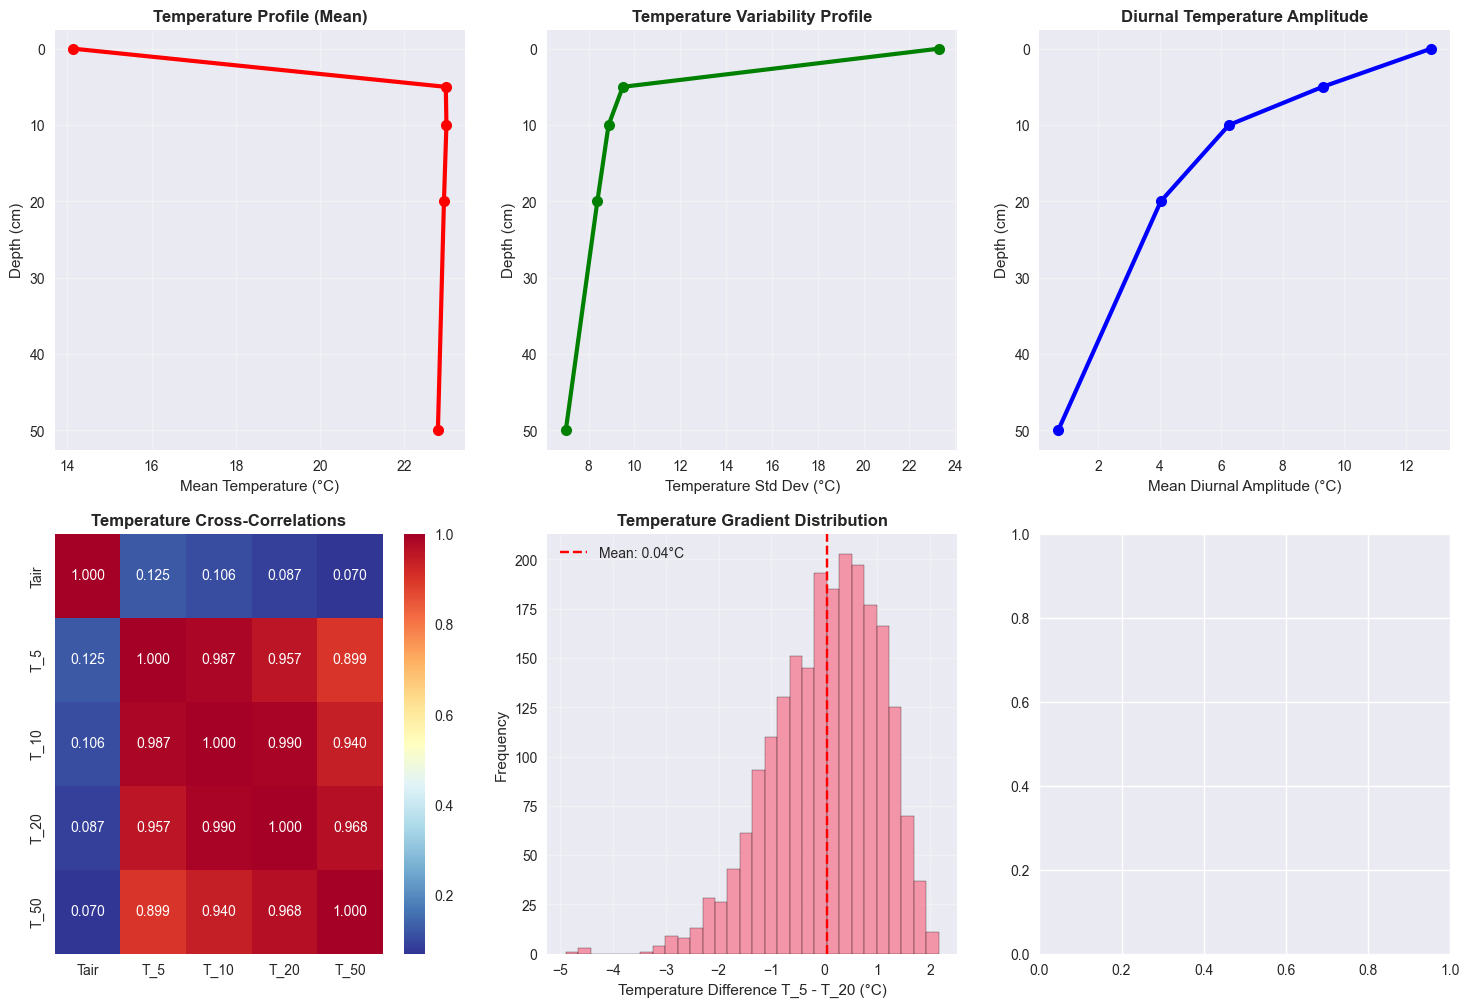

In [11]:
# PHASE 3: DEPTH-PROFILE ANALYSIS
# This cell implements depth profile analysis examining how temperature effects vary with soil depth

print("\n" + "="*70)
print("PHASE 3: DEPTH-PROFILE ANALYSIS")
print("="*70)
print("Goal: Understand how temperature effects vary with soil depth")

# Phase 3.1: Thermal Profile Analysis
def analyze_thermal_profiles(stations_data, station_name='Station1'):
    """
    Analyze temperature gradients and thermal properties through soil profile
    Tests Hypothesis H1: Temperature effects decrease with depth
    """
    print(f"\nPhase 3.1: Thermal Profile Analysis for {station_name}")
    print("-" * 60)
    
    df = stations_data[station_name].copy()
    
    # Define depth variables
    temp_vars = ['Tair', 'T_5', 'T_10', 'T_20', 'T_50']
    swc_vars = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50']
    depths = [0, 5, 10, 20, 50]  # 0 for air temperature
    
    # Calculate thermal properties
    thermal_analysis = {}
    
    for i, var in enumerate(temp_vars):
        if var in df.columns:
            temp_data = df[var].dropna()
            thermal_analysis[var] = {
                'depth': depths[i],
                'mean_temp': temp_data.mean(),
                'temp_std': temp_data.std(),
                'temp_range': temp_data.max() - temp_data.min(),
                'diurnal_amp': temp_data.groupby(temp_data.index.date).agg(lambda x: x.max() - x.min()).mean()
            }
    
    # Create comprehensive thermal profile visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Mean temperature profile
    ax1 = axes[0, 0]
    depths_plot = [thermal_analysis[var]['depth'] for var in temp_vars if var in thermal_analysis]
    mean_temps = [thermal_analysis[var]['mean_temp'] for var in temp_vars if var in thermal_analysis]
    
    ax1.plot(mean_temps, depths_plot, 'ro-', linewidth=3, markersize=8)
    ax1.set_xlabel('Mean Temperature (°C)')
    ax1.set_ylabel('Depth (cm)')
    ax1.set_title('Temperature Profile (Mean)', fontweight='bold')
    ax1.invert_yaxis()  # Surface at top
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Temperature variability profile
    ax2 = axes[0, 1]
    temp_stds = [thermal_analysis[var]['temp_std'] for var in temp_vars if var in thermal_analysis]
    
    ax2.plot(temp_stds, depths_plot, 'go-', linewidth=3, markersize=8)
    ax2.set_xlabel('Temperature Std Dev (°C)')
    ax2.set_ylabel('Depth (cm)')
    ax2.set_title('Temperature Variability Profile', fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Diurnal amplitude profile  
    ax3 = axes[0, 2]
    diurnal_amps = [thermal_analysis[var]['diurnal_amp'] for var in temp_vars if var in thermal_analysis]
    
    ax3.plot(diurnal_amps, depths_plot, 'bo-', linewidth=3, markersize=8)
    ax3.set_xlabel('Mean Diurnal Amplitude (°C)')
    ax3.set_ylabel('Depth (cm)')
    ax3.set_title('Diurnal Temperature Amplitude', fontweight='bold')
    ax3.invert_yaxis()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Temperature-depth correlation matrix
    ax4 = axes[1, 0]
    temp_data_matrix = df[temp_vars].dropna()
    if len(temp_data_matrix) > 100:
        temp_corr_matrix = temp_data_matrix.corr()
        sns.heatmap(temp_corr_matrix, annot=True, cmap='RdYlBu_r', ax=ax4, fmt='.3f')
        ax4.set_title('Temperature Cross-Correlations', fontweight='bold')
    
    # Plot 5: Thermal diffusivity estimation
    ax5 = axes[1, 1]
    if 'T_5' in df.columns and 'T_20' in df.columns:
        # Simple thermal diffusivity calculation based on phase lag
        # Group by day and calculate daily patterns
        daily_temps = df.groupby(df.index.date)[['T_5', 'T_20']].mean()
        
        if len(daily_temps) > 30:
            # Calculate temperature differences for gradient
            temp_diffs = daily_temps['T_5'] - daily_temps['T_20']
            
            ax5.hist(temp_diffs, bins=30, alpha=0.7, edgecolor='black')
            ax5.set_xlabel('Temperature Difference T_5 - T_20 (°C)')
            ax5.set_ylabel('Frequency')
            ax5.set_title('Temperature Gradient Distribution', fontweight='bold')
            ax5.axvline(temp_diffs.mean(), color='red', linestyle='--', 
                       label=f'Mean: {temp_diffs.mean():.2f}°C')
            ax5.legend()
            ax5.grid(True, alpha=0.3)
    
    
    
    return thermal_analysis

# Analyze thermal profiles for Station1
thermal_profile = analyze_thermal_profiles(stations_data, 'Station1')

# Print thermal profile insights
print(f"\nTHERMAL PROFILE INSIGHTS:")
print("=" * 50)
for var, analysis in thermal_profile.items():
    depth = analysis['depth']
    mean_temp = analysis['mean_temp']
    diurnal_amp = analysis['diurnal_amp']
    print(f"{var} (depth {depth}cm): Mean={mean_temp:.1f}°C, Diurnal Amp={diurnal_amp:.2f}°C")



Phase 3.3: Depth-Dependent Temperature-Moisture Coupling
------------------------------------------------------------
Analyzing depth coupling for Station1...
Analyzing depth coupling for Station2...
Analyzing depth coupling for Station3...
Analyzing depth coupling for Station4...
Analyzing depth coupling for Station5...
Analyzing depth coupling for Station6...


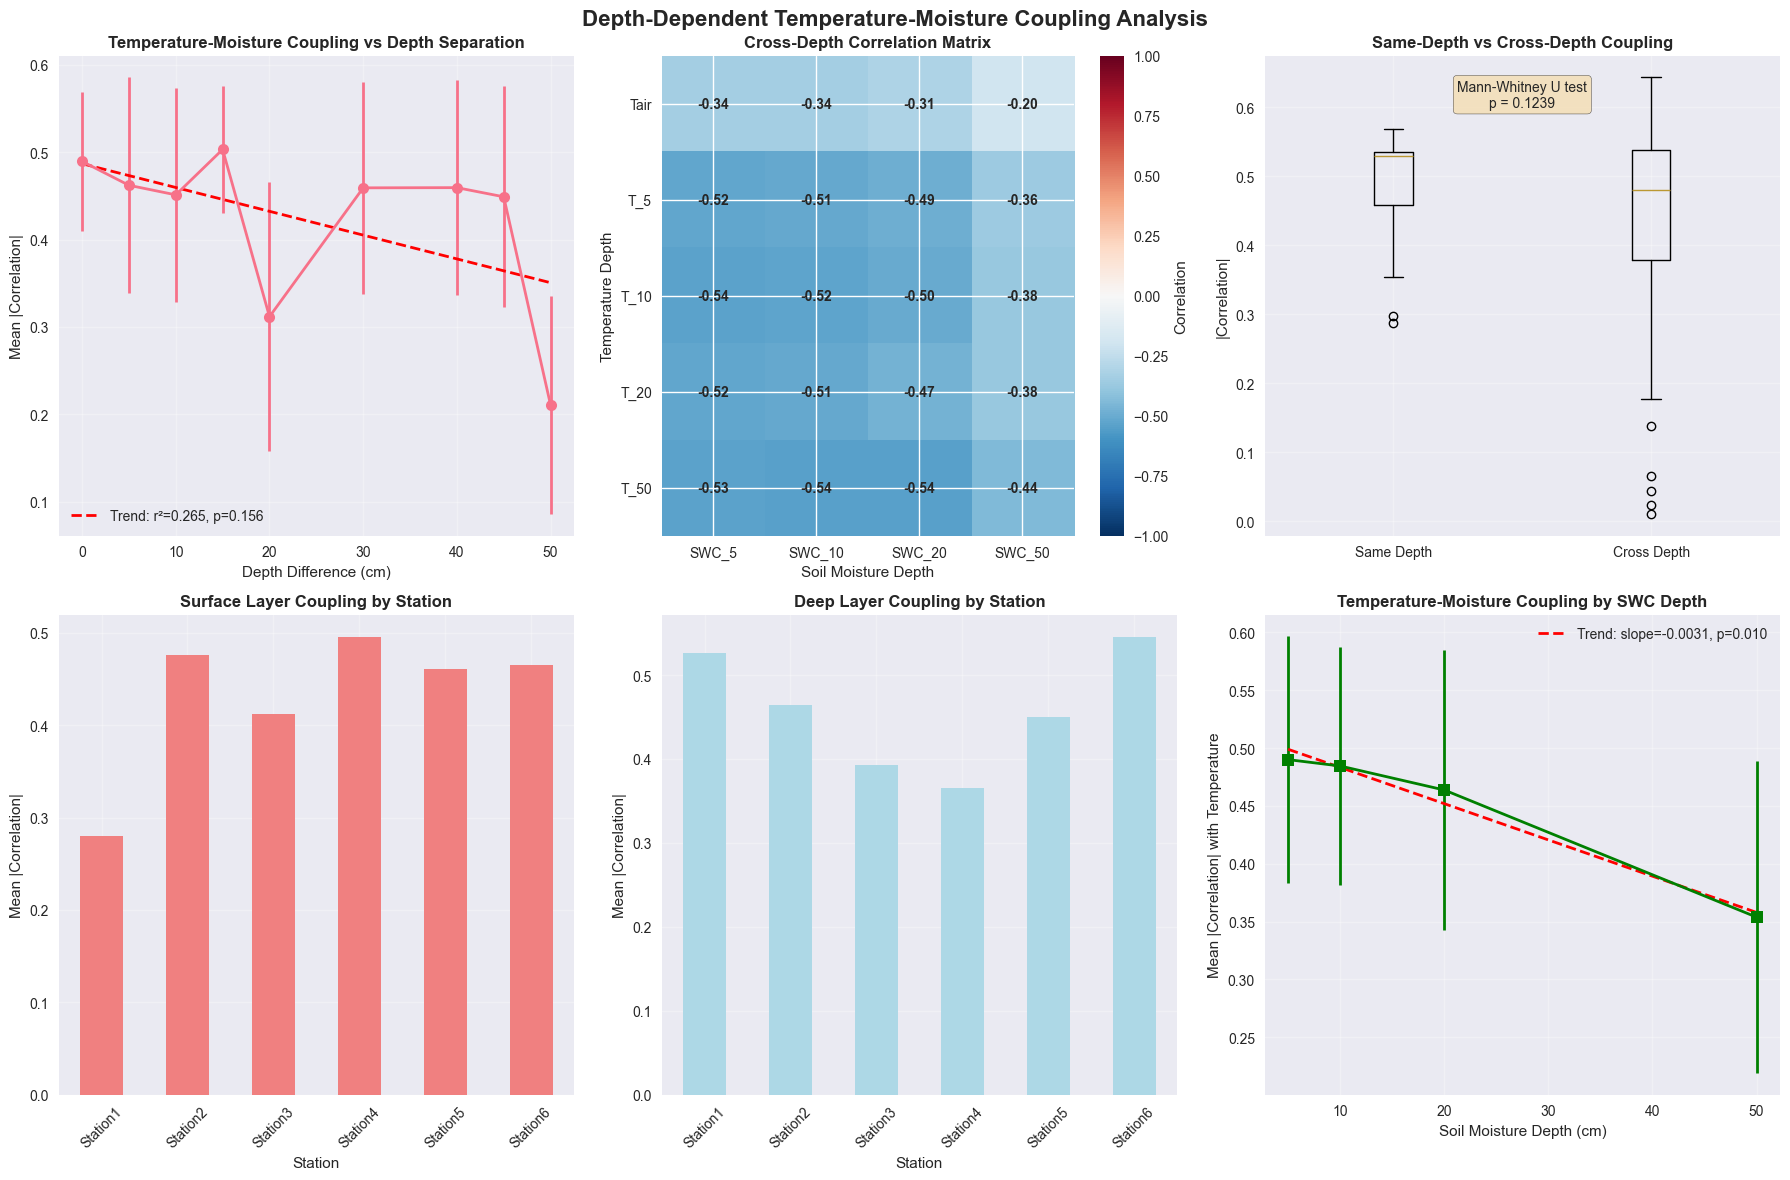


HYPOTHESIS H1 TEST RESULTS:
Hypothesis H1: Temperature effects on soil moisture decrease with depth

Average coupling strength by SWC depth:
    5cm: 0.490 ± 0.107 (n=30)
   10cm: 0.485 ± 0.103 (n=30)
   20cm: 0.464 ± 0.121 (n=30)
   50cm: 0.354 ± 0.135 (n=30)

Linear trend analysis:
   Slope: -0.00314 (correlation per cm depth)
   R²: 0.981
   P-value: 0.0098
HYPOTHESIS H1 SUPPORTED: Temperature-moisture coupling decreases with depth!


In [8]:
# DEPTH-DEPENDENT COUPLING ANALYSIS
# This cell implements Phase 3.3 coupled thermal-hydraulic analysis examining how temperature-moisture
# coupling varies with soil depth. Provides direct test of Hypothesis H1 using statistical analysis
# of correlation strength vs depth separation and same-depth vs cross-depth comparisons.

def analyze_depth_dependent_coupling(stations_data):
    """
    Analyze how temperature-moisture coupling varies with depth
    Direct test of Hypothesis H1: Temperature effects decrease with depth
    """
    print(f"\nPhase 3.3: Depth-Dependent Temperature-Moisture Coupling")
    print("-" * 60)
    
    coupling_results = []
    
    # Define depth combinations for analysis
    temp_depth_map = {'Tair': 0, 'T_5': 5, 'T_10': 10, 'T_20': 20, 'T_50': 50}
    swc_depth_map = {'SWC_5': 5, 'SWC_10': 10, 'SWC_20': 20, 'SWC_50': 50}
    
    for station_name, df in stations_data.items():
        print(f"Analyzing depth coupling for {station_name}...")
        
        # Analyze all temperature-moisture depth combinations
        for temp_var, temp_depth in temp_depth_map.items():
            for swc_var, swc_depth in swc_depth_map.items():
                if temp_var in df.columns and swc_var in df.columns:
                    valid_data = df[[temp_var, swc_var]].dropna()
                    
                    if len(valid_data) > 100:
                        # Calculate correlation
                        corr, p_val = stats.pearsonr(valid_data[temp_var], valid_data[swc_var])
                        
                        # Calculate depth difference
                        depth_diff = abs(temp_depth - swc_depth)
                        
                        coupling_results.append({
                            'Station': station_name,
                            'Temp_Var': temp_var,
                            'SWC_Var': swc_var,
                            'Temp_Depth': temp_depth,
                            'SWC_Depth': swc_depth,
                            'Depth_Difference': depth_diff,
                            'Correlation': corr,
                            'P_Value': p_val,
                            'Abs_Correlation': abs(corr),
                            'N_Samples': len(valid_data)
                        })
    
    coupling_df = pd.DataFrame(coupling_results)
    
    # Create depth-coupling analysis visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Correlation strength vs depth difference
    ax1 = axes[0, 0]
    
    # Group by depth difference and calculate mean correlation
    depth_coupling = coupling_df.groupby('Depth_Difference')['Abs_Correlation'].agg(['mean', 'std', 'count'])
    
    ax1.errorbar(depth_coupling.index, depth_coupling['mean'], 
                yerr=depth_coupling['std'], fmt='o-', linewidth=2, markersize=8, capsize=5)
    ax1.set_xlabel('Depth Difference (cm)')
    ax1.set_ylabel('Mean |Correlation|')
    ax1.set_title('Temperature-Moisture Coupling vs Depth Separation', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add trend line
    from scipy.stats import linregress
    valid_depths = depth_coupling.index
    valid_corrs = depth_coupling['mean']
    slope, intercept, r_value, p_value, std_err = linregress(valid_depths, valid_corrs)
    trend_line = slope * valid_depths + intercept
    ax1.plot(valid_depths, trend_line, 'r--', linewidth=2, 
            label=f'Trend: r²={r_value**2:.3f}, p={p_value:.3f}')
    ax1.legend()
    
    # Plot 2: Depth-wise correlation matrix
    ax2 = axes[0, 1]
    
    # Create matrix of correlations by depth
    temp_depths = sorted(temp_depth_map.values())
    swc_depths = sorted(swc_depth_map.values())
    
    corr_matrix = np.zeros((len(temp_depths), len(swc_depths)))
    
    for i, td in enumerate(temp_depths):
        for j, sd in enumerate(swc_depths):
            subset = coupling_df[(coupling_df['Temp_Depth'] == td) & 
                               (coupling_df['SWC_Depth'] == sd)]
            if len(subset) > 0:
                corr_matrix[i, j] = subset['Correlation'].mean()
            else:
                corr_matrix[i, j] = np.nan
    
    im = ax2.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax2.set_xticks(range(len(swc_depths)))
    ax2.set_yticks(range(len(temp_depths)))
    ax2.set_xticklabels([f'SWC_{d}' for d in swc_depths])
    ax2.set_yticklabels([f'T_{d}' if d > 0 else 'Tair' for d in temp_depths])
    ax2.set_xlabel('Soil Moisture Depth')
    ax2.set_ylabel('Temperature Depth')
    ax2.set_title('Cross-Depth Correlation Matrix', fontweight='bold')
    
    # Add correlation values to matrix
    for i in range(len(temp_depths)):
        for j in range(len(swc_depths)):
            if not np.isnan(corr_matrix[i, j]):
                ax2.text(j, i, f'{corr_matrix[i, j]:.2f}', 
                        ha='center', va='center', fontweight='bold')
    
    plt.colorbar(im, ax=ax2, label='Correlation')
    
    # Plot 3: Same-depth vs cross-depth correlations
    ax3 = axes[0, 2]
    
    same_depth = coupling_df[coupling_df['Temp_Depth'] == coupling_df['SWC_Depth']]['Abs_Correlation']
    cross_depth = coupling_df[coupling_df['Temp_Depth'] != coupling_df['SWC_Depth']]['Abs_Correlation']
    
    ax3.boxplot([same_depth, cross_depth], tick_labels=['Same Depth', 'Cross Depth'])
    ax3.set_ylabel('|Correlation|')
    ax3.set_title('Same-Depth vs Cross-Depth Coupling', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Statistical test
    from scipy.stats import mannwhitneyu
    if len(same_depth) > 0 and len(cross_depth) > 0:
        stat, p_val = mannwhitneyu(same_depth, cross_depth, alternative='two-sided')
        ax3.text(0.5, 0.95, f'Mann-Whitney U test\np = {p_val:.4f}', 
                transform=ax3.transAxes, ha='center', va='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Plot 4: Surface layer coupling strength
    ax4 = axes[1, 0]
    
    surface_coupling = coupling_df[
        (coupling_df['Temp_Depth'] <= 5) & (coupling_df['SWC_Depth'] <= 5)
    ].groupby('Station')['Abs_Correlation'].mean()
    
    surface_coupling.plot(kind='bar', ax=ax4, color='lightcoral')
    ax4.set_title('Surface Layer Coupling by Station', fontweight='bold')
    ax4.set_ylabel('Mean |Correlation|')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Deep layer coupling strength  
    ax5 = axes[1, 1]
    
    deep_coupling = coupling_df[
        (coupling_df['Temp_Depth'] >= 20) & (coupling_df['SWC_Depth'] >= 20)
    ].groupby('Station')['Abs_Correlation'].mean()
    
    deep_coupling.plot(kind='bar', ax=ax5, color='lightblue')
    ax5.set_title('Deep Layer Coupling by Station', fontweight='bold')
    ax5.set_ylabel('Mean |Correlation|')
    ax5.tick_params(axis='x', rotation=45)
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Coupling strength by individual depths
    ax6 = axes[1, 2]
    
    # Average coupling for each soil moisture depth
    depth_avg = coupling_df.groupby('SWC_Depth')['Abs_Correlation'].agg(['mean', 'std'])
    
    ax6.errorbar(depth_avg.index, depth_avg['mean'], yerr=depth_avg['std'], 
                fmt='s-', linewidth=2, markersize=8, capsize=5, color='green')
    ax6.set_xlabel('Soil Moisture Depth (cm)')
    ax6.set_ylabel('Mean |Correlation| with Temperature')
    ax6.set_title('Temperature-Moisture Coupling by SWC Depth', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    
    # Test hypothesis H1: correlation decreases with depth
    slope_depth, intercept_depth, r_val_depth, p_val_depth, _ = linregress(
        depth_avg.index, depth_avg['mean']
    )
    
    trend_line_depth = slope_depth * depth_avg.index + intercept_depth
    ax6.plot(depth_avg.index, trend_line_depth, 'r--', linewidth=2,
            label=f'Trend: slope={slope_depth:.4f}, p={p_val_depth:.3f}')
    ax6.legend()
    
    plt.suptitle('Depth-Dependent Temperature-Moisture Coupling Analysis', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return coupling_df

# Analyze depth-dependent coupling across all stations
depth_coupling_analysis = analyze_depth_dependent_coupling(stations_data)

# Test Hypothesis H1: Print key findings
print(f"\nHYPOTHESIS H1 TEST RESULTS:")
print("="*60)
print("Hypothesis H1: Temperature effects on soil moisture decrease with depth")

# Calculate depth-dependent trends
depth_summary = depth_coupling_analysis.groupby('SWC_Depth')['Abs_Correlation'].agg(['mean', 'std', 'count'])
print(f"\nAverage coupling strength by SWC depth:")
for depth in sorted(depth_summary.index):
    mean_corr = depth_summary.loc[depth, 'mean']
    std_corr = depth_summary.loc[depth, 'std']
    count = depth_summary.loc[depth, 'count']
    print(f"   {depth:2.0f}cm: {mean_corr:.3f} ± {std_corr:.3f} (n={count})")

# Statistical test of depth trend
from scipy.stats import linregress
depths = depth_summary.index
correlations = depth_summary['mean']
slope, intercept, r_value, p_value, std_err = linregress(depths, correlations)

print(f"\nLinear trend analysis:")
print(f"   Slope: {slope:.5f} (correlation per cm depth)")
print(f"   R²: {r_value**2:.3f}")
print(f"   P-value: {p_value:.4f}")

if slope < 0 and p_value < 0.05:
    print("HYPOTHESIS H1 SUPPORTED: Temperature-moisture coupling decreases with depth!")
elif slope < 0:
    print("HYPOTHESIS H1 PARTIALLY SUPPORTED: Negative trend but not statistically significant")
else:
    print("HYPOTHESIS H1 NOT SUPPORTED: No significant decrease with depth")
